In [104]:
"""Following the reference from Medium"""
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.optim as optim

In [105]:
transform = transforms.Compose([transforms.ToTensor()])

# Had to delete my previously downloaded MNIST dataset before installing
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 100
train_loader = DataLoader(dataset=mnist_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=mnist_test, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

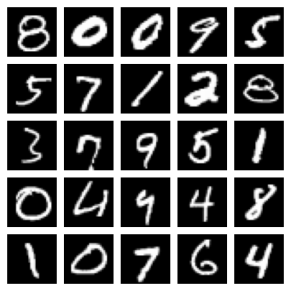

In [106]:
"""Visualize the dataset"""
dataiter = iter(train_loader)
image = next(dataiter)

num_samples = 25
sample_images = image[0][:num_samples, 0]

fig = plt.figure(figsize=(5, 5))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

for ax, im in zip(grid, sample_images):
    ax.imshow(im, cmap='gray')
    ax.axis('off')

plt.show()

In [107]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_num=400, latent_dim=8):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_num),
            nn.ReLU(),
            nn.Linear(hidden_num, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_num),
            nn.ReLU(),
            nn.Linear(hidden_num, input_dim),
            nn.Sigmoid()
        )
    
    def decode(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [128]:
model = Autoencoder(latent_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [129]:
num_epochs = 10
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.view(data.size(0), -1)
        data = data.to(device)
        encoded, decoded = model(data)

        # Forward pass
        loss = criterion(decoded, data)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    epoch_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/10], Loss: 0.0345
Epoch [2/10], Loss: 0.0154
Epoch [3/10], Loss: 0.0132
Epoch [4/10], Loss: 0.0120
Epoch [5/10], Loss: 0.0112
Epoch [6/10], Loss: 0.0107
Epoch [7/10], Loss: 0.0102
Epoch [8/10], Loss: 0.0099
Epoch [9/10], Loss: 0.0096
Epoch [10/10], Loss: 0.0094


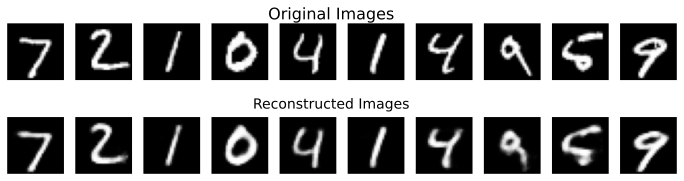

In [130]:
model.eval()
with torch.no_grad():
    data_iter = iter(test_loader)
    original_images, _ = next(data_iter)

    original_images = original_images.view(batch_size, -1).to(device)

    _, reconstructed_images = model(original_images)
    reconstructed_images = reconstructed_images.cpu().view(-1, 28, 28)
    original_images = original_images.cpu().view(-1, 28, 28)

    num_images = 10
    fig, axes = plt.subplots(2, num_images, figsize=(12, 3.1))

    for i in range(num_images):
        axes[0, i].imshow(original_images[i], cmap='gray')
        axes[0, i].axis('off')
        # axes[0, i].set_title('Original Image')

        axes[1, i].imshow(reconstructed_images[i], cmap='gray')
        axes[1, i].axis('off')
        # axes[1, i].set_title('Reconstructed Image')

    fig.text(0.5, 0.85, 'Original Images', ha='center', fontsize=16)
    fig.text(0.5, 0.45, 'Reconstructed Images', ha='center', fontsize=14)
    plt.subplots_adjust(hspace=0.2)
    plt.show()

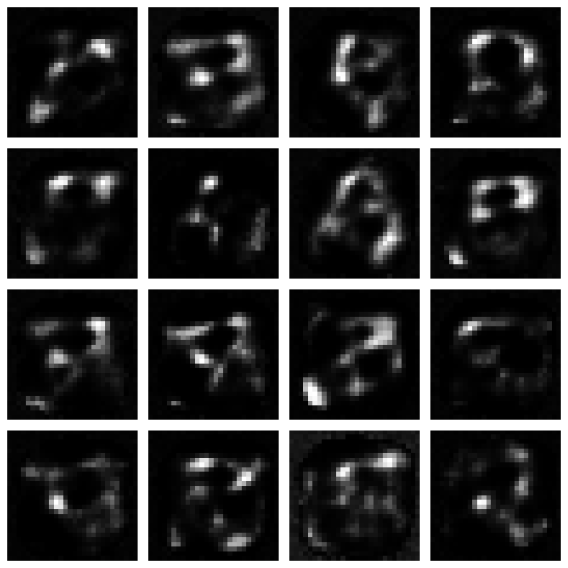

In [131]:
n_samples = 16
latent_dim = 32

model.eval()
with torch.no_grad():
    z = torch.randn(n_samples, latent_dim).to(device)
    generated = model.decode(z).cpu()

generated = generated.view(-1, 28, 28)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [133]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        # Just 2 fc layers for encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim),
            nn.LeakyReLU(0.2)
        )
        
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)

        # 3 WHOLE fc layers for decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, latent_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar
    
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)
        z = mean + var * epsilon
        return z
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        return self.decode(z), mean, logvar

In [134]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [135]:
def loss_function(x, x_hat, mean, log_var):
    repro_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return repro_loss + KLD

def train(model, optimizer, epochs, device):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, -1).to(device)
            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch: {} \tLoss: {}".format(epoch + 1, total_loss /(batch_idx*batch_size)))
    return total_loss


In [136]:
train(model, optimizer, epochs=50, device=device)

	Epoch: 1 	Loss: 178.7322300350845
	Epoch: 2 	Loss: 157.7203297651033
	Epoch: 3 	Loss: 153.03524309721934
	Epoch: 4 	Loss: 150.0996678546275
	Epoch: 5 	Loss: 147.9707538769042
	Epoch: 6 	Loss: 146.45149526554675
	Epoch: 7 	Loss: 145.17311779397954
	Epoch: 8 	Loss: 143.88406794527336
	Epoch: 9 	Loss: 143.10330529724018
	Epoch: 10 	Loss: 142.19648892359663
	Epoch: 11 	Loss: 141.6567277004643
	Epoch: 12 	Loss: 140.9357531269564
	Epoch: 13 	Loss: 140.43782865648475
	Epoch: 14 	Loss: 140.10084623460978
	Epoch: 15 	Loss: 139.52761650276503
	Epoch: 16 	Loss: 139.1628591761008
	Epoch: 17 	Loss: 138.58366387012208
	Epoch: 18 	Loss: 138.31963684591506
	Epoch: 19 	Loss: 138.12332380138773
	Epoch: 20 	Loss: 137.71855335063648
	Epoch: 21 	Loss: 137.59480807856843
	Epoch: 22 	Loss: 137.22908896011583
	Epoch: 23 	Loss: 137.1116041873174
	Epoch: 24 	Loss: 136.75253291618844
	Epoch: 25 	Loss: 136.56456895933326
	Epoch: 26 	Loss: 136.44982938686874
	Epoch: 27 	Loss: 136.18483713089523
	Epoch: 28 	Loss: 

7970000.681640625

In [137]:
def generate_digit(mean, var):
    z_sample = torch.tensor([[mean, var]], dtype=torch.float).to(device)
    x_decoded = model.decode(z_sample)
    digit = x_decoded.detach().cpu().reshape(28, 28)
    plt.imshow(digit, cmap='gray')
    plt.axis('off')
    plt.show()

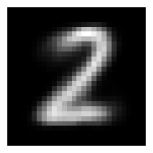

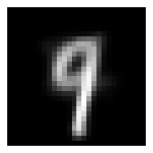

(None, None)

In [138]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

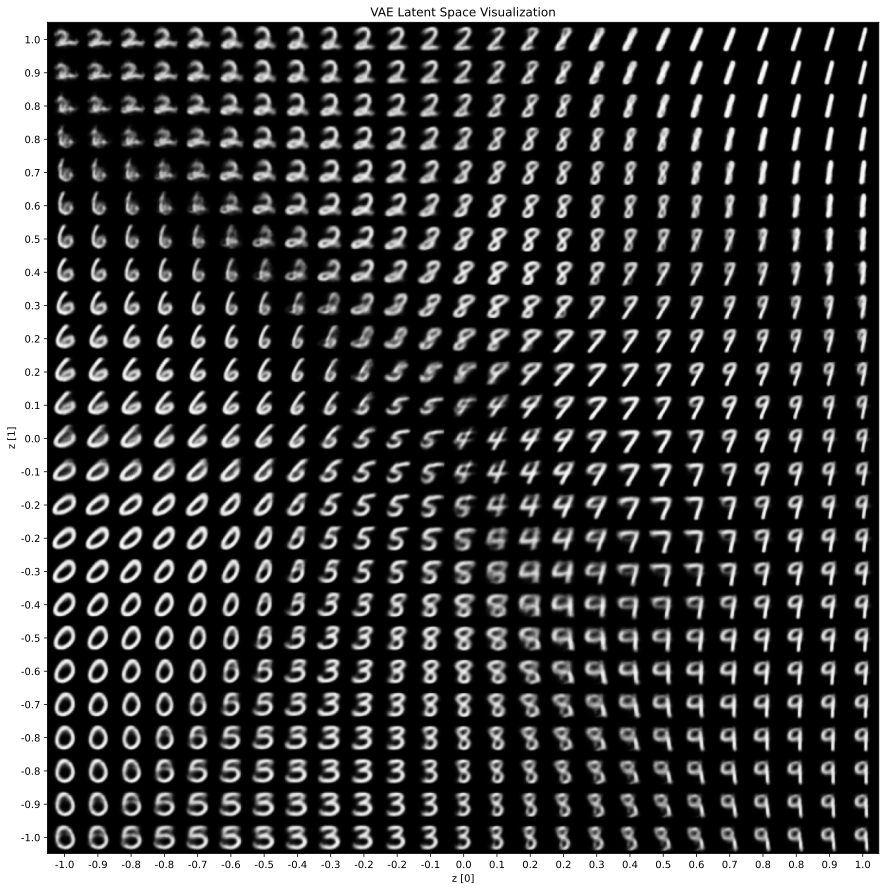

In [142]:
def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z [0]")
    plt.ylabel("z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(model)

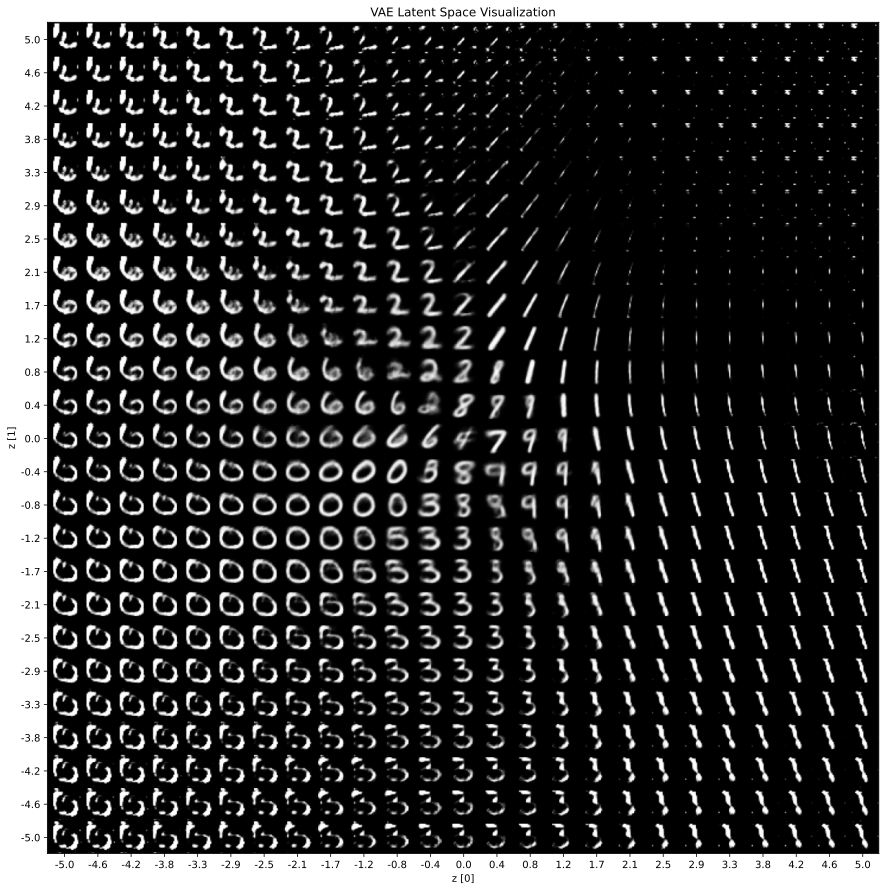

In [141]:
plot_latent_space(model, scale=5.0)

In [86]:
"""GANs"""
from d2l import torch as d2l
import torchvision
import warnings
d2l.DATA_HUB['pokemon'] = (d2l.DATA_URL + 'pokemon.zip',
                           'c065c0e2593b8b161a2d7873e42418bf6a21106c')

data_dir = d2l.download_extract('pokemon')
pokemon = torchvision.datasets.ImageFolder(data_dir)

In [87]:
batch_size = 256
transformer = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)
])
pokemon.transform = transformer
data_iter = torch.utils.data.DataLoader(
    pokemon, batch_size=batch_size,
    shuffle=True, num_workers=d2l.get_dataloader_workers())


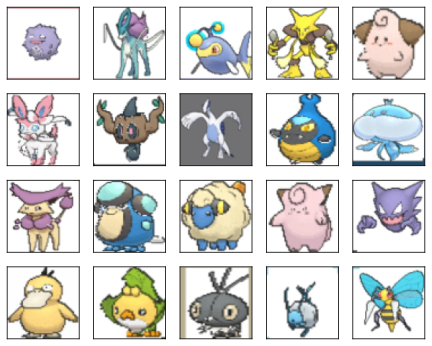

In [88]:
"""Visualize"""
warnings.filterwarnings('ignore')
d2l.set_figsize((4, 4))
for X, y in data_iter:
    imgs = X[:20,:,:,:].permute(0, 2, 3, 1)/2+0.5
    d2l.show_images(imgs, num_rows=4, num_cols=5)
    break


In [89]:
class G_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                 padding=1, **kwargs):
        super(G_block, self).__init__(**kwargs)
        self.conv2d_trans = nn.ConvTranspose2d(in_channels, out_channels,
                                kernel_size, strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d_trans(X)))


In [90]:
x = torch.zeros((2, 3, 16, 16))
g_blk = G_block(20)
g_blk(x).shape


torch.Size([2, 20, 32, 32])

In [91]:
x = torch.zeros((2, 3, 1, 1))
g_blk = G_block(20, strides=1, padding=0)
g_blk(x).shape


torch.Size([2, 20, 4, 4])

In [92]:
n_G = 64
net_G = nn.Sequential(
    G_block(in_channels=100, out_channels=n_G*8,
            strides=1, padding=0),                  # Output: (64 * 8, 4, 4)
    G_block(in_channels=n_G*8, out_channels=n_G*4), # Output: (64 * 4, 8, 8)
    G_block(in_channels=n_G*4, out_channels=n_G*2), # Output: (64 * 2, 16, 16)
    G_block(in_channels=n_G*2, out_channels=n_G),   # Output: (64, 32, 32)
    nn.ConvTranspose2d(in_channels=n_G, out_channels=3,
                       kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh())  # Output: (3, 64, 64)


In [93]:
x = torch.zeros((1, 100, 1, 1))
net_G(x).shape


torch.Size([1, 3, 64, 64])

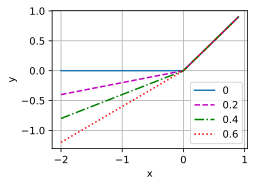

In [94]:
alphas = [0, .2, .4, .6, .8, 1]
x = torch.arange(-2, 1, 0.1)
Y = [nn.LeakyReLU(alpha)(x).detach().numpy() for alpha in alphas]
d2l.plot(x.detach().numpy(), Y, 'x', 'y', alphas)


In [ ]:
class D_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                padding=1, alpha=0.2, **kwargs):
        super(D_block, self).__init__(**kwargs)
        self.conv2d = nn.Conv2d(in_channels, out_channels, kernel_size,
                                strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        # self.activation = nn.LeakyReLU(alpha, inplace=True)
        self.activation = nn.ReLU()

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d(X)))


In [96]:
x = torch.zeros((2, 3, 16, 16))
d_blk = D_block(20)
d_blk(x).shape


torch.Size([2, 20, 8, 8])

In [97]:
n_D = 64
net_D = nn.Sequential(
    D_block(n_D),  # Output: (64, 32, 32)
    D_block(in_channels=n_D, out_channels=n_D*2),  # Output: (64 * 2, 16, 16)
    D_block(in_channels=n_D*2, out_channels=n_D*4),  # Output: (64 * 4, 8, 8)
    D_block(in_channels=n_D*4, out_channels=n_D*8),  # Output: (64 * 8, 4, 4)
    nn.Conv2d(in_channels=n_D*8, out_channels=1,
              kernel_size=4, bias=False))  # Output: (1, 1, 1)


In [98]:
x = torch.zeros((1, 3, 64, 64))
net_D(x).shape


torch.Size([1, 1, 1, 1])

In [99]:
def train(net_D, net_G, data_iter, num_epochs, lr, latent_dim,
          device=d2l.try_gpu()):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    net_D, net_G = net_D.to(device), net_G.to(device)
    trainer_hp = {'lr': lr, 'betas': [0.5,0.999]}
    trainer_D = torch.optim.Adam(net_D.parameters(), **trainer_hp)
    trainer_G = torch.optim.Adam(net_G.parameters(), **trainer_hp)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    for epoch in range(1, num_epochs + 1):
        # Train one epoch
        timer = d2l.Timer()
        metric = d2l.Accumulator(3)  # loss_D, loss_G, num_examples
        for X, _ in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim, 1, 1))
            X, Z = X.to(device), Z.to(device)
            metric.add(d2l.update_D(X, Z, net_D, net_G, loss, trainer_D),
                       d2l.update_G(Z, net_D, net_G, loss, trainer_G),
                       batch_size)
        # Show generated examples
        Z = torch.normal(0, 1, size=(21, latent_dim, 1, 1), device=device)
        # Normalize the synthetic data to N(0, 1)
        fake_x = net_G(Z).permute(0, 2, 3, 1) / 2 + 0.5
        imgs = torch.cat(
            [torch.cat([
                fake_x[i * 7 + j].cpu().detach() for j in range(7)], dim=1)
             for i in range(len(fake_x)//7)], dim=0)
        animator.axes[1].cla()
        animator.axes[1].imshow(imgs)
        # Show the losses
        loss_D, loss_G = metric[0] / metric[2], metric[1] / metric[2]
        animator.add(epoch, (loss_D, loss_G))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, '
          f'{metric[2] / timer.stop():.1f} examples/sec on {str(device)}')


loss_D 0.200, loss_G 7.391, 3499.9 examples/sec on cuda:0


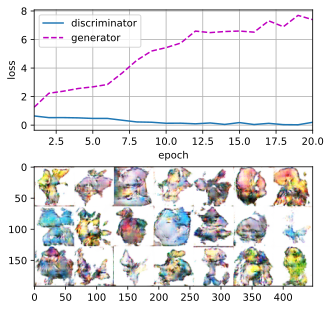

In [100]:
latent_dim, lr, num_epochs = 100, 0.005, 20
train(net_D, net_G, data_iter, num_epochs, lr, latent_dim)
